# Part 5, Topic 1: ChipWhisperer CPA Attacks in Practice


---
NOTE: This lab references some (commercial) training material on [ChipWhisperer.io](https://www.ChipWhisperer.io). You can freely execute and use the lab per the open-source license (including using it in your own courses if you distribute similarly), but you must maintain notice about this source location. Consider joining our training course to enjoy the full experience.

---

**SUMMARY:** *Last time, we went into detail of the various outputs from a CPA attack. This lab gives you a useful starting point for the attack itself.*

**LEARNING OUTCOMES:**

* Build a CPA attack without all the "extra documentation" around it from previous labs.
* Learn about getting data into the expected format.

## Prerequisites

Hold up! Before you continue, check you've done the following tutorials:

* ☑ ChipWhisperer Analyzer CPA Attack (you should have used the analyzer code before).
* ☑ SCA101 Intro (you should have an idea of how to get hardware-specific versions running).

## Connect and Program

In [1]:
SCOPETYPE = 'OPENADC'
PLATFORM = 'CWLITEXMEGA'
CRYPTO_TARGET='TINYAES128C'
SS_VER='SS_VER_1_1'

In [2]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd ../../../firmware/mcu/simpleserial-aes
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3

Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (Homebrew AVR GCC 9.5.0) 9.5.0
Copyright (C) 2019 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     simpleserial-aes.c ...
-e Done!
.
Compiling:
-en     .././simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     .././hal/hal.c ...
-e Done!
.
Compiling:
-en     .././hal//xmega/XMEGA_AES_driver.c ...
-e Done!
.
Compiling:
-en     .././hal//xmega/uart.c ...
-e Done!
.
Compiling:
-en     .././hal//xmega/usart_driver.c ...
-e Done!
.
Compiling:
-en     .././hal//xmega/xmega_hal.c ...
-e Done!
.
Compiling:
-en     .././crypto/tiny-AES128-C/aes.c ...
-e Done!
.
Compiling:
-en     .././

In [3]:
%run "../../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 7317185                   to 21127925                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 22377513                  to 25595718                 
scope.clock.adc_rate                     changed from 22377513.0                to 25595718.0        

In [4]:
# If you need to program - run this
fw_path = '../../../firmware/mcu/simpleserial-aes/simpleserial-aes-{}.hex'.format(PLATFORM)
cw.program_target(scope, prog, fw_path)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4277 bytes


In [5]:
# Reset target to kick us off
reset_target(scope)

## Capture

In [6]:
#Do any special setup here?

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
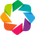

:DynamicMap   []
   :Curve   [index]   (y)

In [7]:
%run "../../Helper_Scripts/plot.ipynb"
plot = real_time_plot(plot_len=3000)

In [8]:
from tqdm.notebook import trange
ktp = cw.ktp.Basic()

#Set your project name here
project = cw.create_project("projects/lab51_examplecpa", overwrite = True)

#Set your number of traces here
num_traces = 250

for i in trange(num_traces, desc='Capturing traces'):
    key, text = ktp.next()  # manual creation of a key, text pair can be substituted here
    trace = cw.capture_trace(scope, target, text, key)
    if trace is None:
        continue
    project.traces.append(trace)
    
    #Send every 10th trace?
    if i % 10 == 0:
        plot.send(trace)
        
project.save()

Capturing traces:   0%|          | 0/250 [00:00<?, ?it/s]

In [9]:
#If you don't need scope anymore - run this block
scope.dis()
target.dis()

## Analysis

In [10]:
import chipwhisperer.analyzer as cwa
#pick right leakage model for your attack
leak_model = cwa.leakage_models.sbox_output
attack = cwa.cpa(project, leak_model)
results = attack.run(cwa.get_jupyter_callback(attack))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,2B0.762,7E0.771,150.826,160.800,280.822,AE0.914,D20.791,A60.781,AB0.792,F70.925,150.922,880.895,090.791,CF0.828,4F0.839,3C0.913
1,DB0.381,DC0.337,200.372,940.330,F10.339,A30.344,150.335,0E0.345,680.320,AC0.352,AD0.324,1E0.323,7A0.336,F20.326,850.327,D00.308
2,180.347,F20.332,1F0.342,2B0.327,DE0.322,300.308,4B0.304,940.331,300.317,6B0.323,8C0.317,9F0.318,1F0.318,620.298,B00.301,C70.299
3,150.318,4E0.315,2B0.323,480.324,650.304,7D0.303,020.295,F60.325,B00.316,020.313,2B0.309,2B0.315,1A0.287,130.287,F70.300,B40.298
4,360.314,2F0.311,B70.319,8F0.312,D80.302,650.302,AC0.290,950.319,0B0.314,590.313,A30.306,F80.310,460.287,FF0.280,CF0.293,760.298


### LASCAR Quick Setup

In [ ]:
!pip install git+https://github.com/Ledger-Donjon/lascar.git
!pip install scikit-learn

In [ ]:
!pip install h5py

In [ ]:
!pip install progressbar2

In [ ]:
import lascar

In [11]:
import chipwhisperer.common.api.lascar as cw_lascar
from lascar import *
cw_container = cw_lascar.CWContainer(project, project.textins)
cpa_engines = [CpaEngine(name="cpa_%02d" % i, selection_function=cw_lascar.sbox_HW_gen(i), guess_range=range(256)) for i in range(16)]
session = Session(cw_container, engines=cpa_engines).run(batch_size=50)

2026-06-19 16:33:03,347 - lascar.session - INFO - Session Session: 250 traces, 18 engines, batch_size=50, leakage_shape=(5000,)
INFO:lascar.session:Session Session: 250 traces, 18 engines, batch_size=50, leakage_shape=(5000,)
Session |100%||250 trc/250 | (18 engines, batch_size=50, leakage_shape=(5000,)) |Time:  0:00:0501


In [12]:
import chipwhisperer.analyzer as cwa
disp = cw_lascar.LascarDisplay(cpa_engines, list(project.keys[0]))
disp.show_pge()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2B0.762,7E0.771,150.826,160.800,280.822,AE0.914,D20.791,A60.781,AB0.792,F70.925,150.922,880.895,090.791,CF0.828,4F0.839,3C0.913
1,DB0.381,DC0.337,200.372,940.330,F10.339,A30.344,150.335,0E0.345,680.320,AC0.352,AD0.324,1E0.323,7A0.336,F20.326,850.327,D00.308
2,180.347,F20.332,1F0.342,2B0.327,DE0.322,300.308,4B0.304,940.331,300.317,6B0.323,8C0.317,9F0.318,1F0.318,620.298,B00.301,C70.299
3,150.318,4E0.315,2B0.323,480.324,650.304,7D0.303,020.295,F60.325,B00.316,020.313,2B0.309,2B0.315,1A0.287,130.287,F70.300,B40.298
4,360.314,2F0.311,B70.319,8F0.312,D80.302,650.302,AC0.290,950.319,0B0.314,590.313,A30.306,F80.310,460.287,FF0.280,CF0.293,760.298
5,1F0.311,BB0.307,520.316,6D0.312,660.299,B80.300,1B0.289,3F0.314,1A0.300,B60.302,FF0.303,C00.302,7E0.286,820.278,900.291,270.291
6,700.303,380.300,2A0.316,860.305,170.297,500.293,440.288,0F0.314,940.300,980.301,0A0.303,890.301,4F0.283,680.278,A50.289,2C0.290
7,EB0.297,F30.299,1B0.309,600.290,A60.293,200.286,840.282,E70.312,C70.300,3B0.300,3C0.302,FD0.295,AE0.282,0D0.278,2D0.288,F40.289
8,DE0.296,1B0.298,EE0.301,A40.286,100.291,EF0.283,240.279,DE0.312,8D0.292,5F0.298,E00.298,580.295,FC0.281,4B0.277,3F0.287,FB0.288
9,D10.296,AE0.298,1A0.295,2F0.286,520.286,DB0.281,370.278,0C0.308,560.291,9B0.290,1C0.298,D70.295,670.277,6A0.275,BA0.282,2D0.287


---
<small>NO-FUN DISCLAIMER: This material is Copyright (C) NewAE Technology Inc., 2015-2020. ChipWhisperer is a trademark of NewAE Technology Inc., claimed in all jurisdictions, and registered in at least the United States of America, European Union, and Peoples Republic of China.

Tutorials derived from our open-source work must be released under the associated open-source license, and notice of the source must be *clearly displayed*. Only original copyright holders may license or authorize other distribution - while NewAE Technology Inc. holds the copyright for many tutorials, the github repository includes community contributions which we cannot license under special terms and **must** be maintained as an open-source release. Please contact us for special permissions (where possible).

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.</small>